# EDA

In [19]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import configparser
import numpy as np

In [37]:
df = pd.read_csv('../data/AEP_hourly.csv', parse_dates = ["Datetime"])
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [21]:
# Checking for any null row.
df.isnull().sum()

Datetime    0
AEP_MW      0
dtype: int64

In [38]:
#Converting Datetime column to datetime type
df.sort_values('Datetime')
print(df['Datetime'].dtype)

datetime64[ns]


In [31]:
# Graph for datetime vs Energy consumption
# Daily graph
df_daily = (
    df.set_index('Datetime')
      .resample('D')
      .mean()
      .reset_index()
)

df_monthly = (
    df.set_index('Datetime')
      .resample('M')
      .mean()
      .reset_index()
)

/tmp/ipykernel_5329/3282202571.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


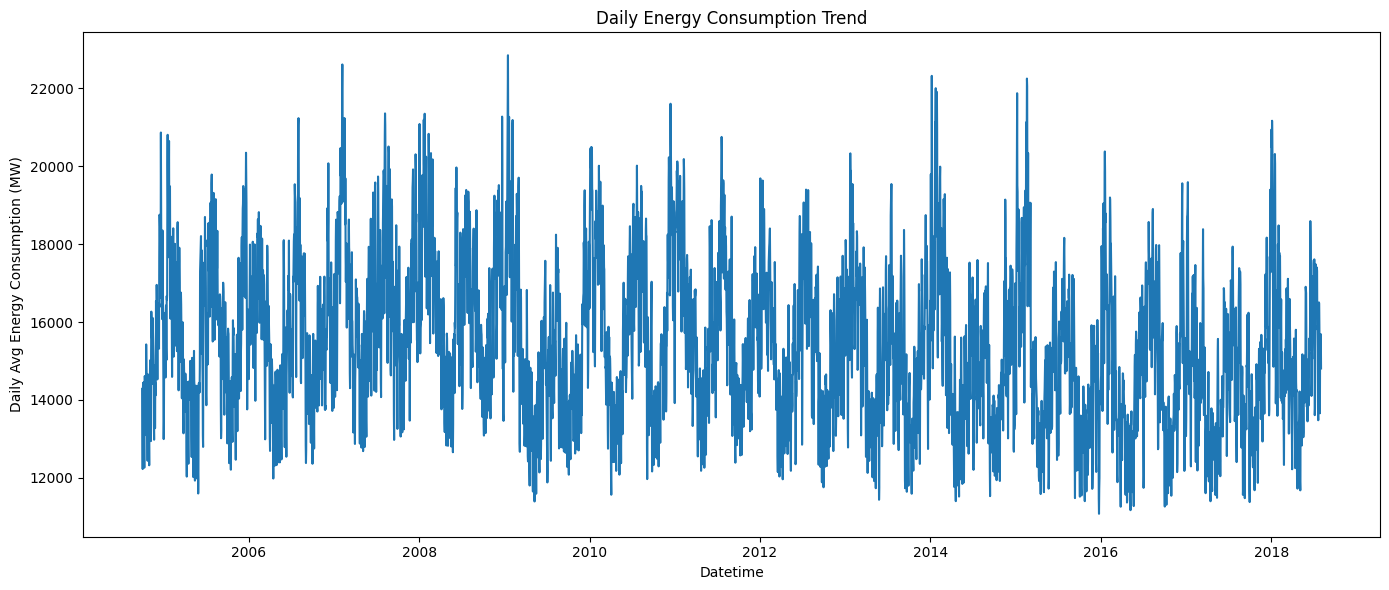

In [34]:
plt.figure(figsize=(14, 6))
plt.plot(df_daily['Datetime'], df_daily['AEP_MW'])
plt.xlabel("Datetime")
plt.ylabel("Daily Avg Energy Consumption (MW)")
plt.title("Daily Energy Consumption Trend")
plt.tight_layout()
plt.show()

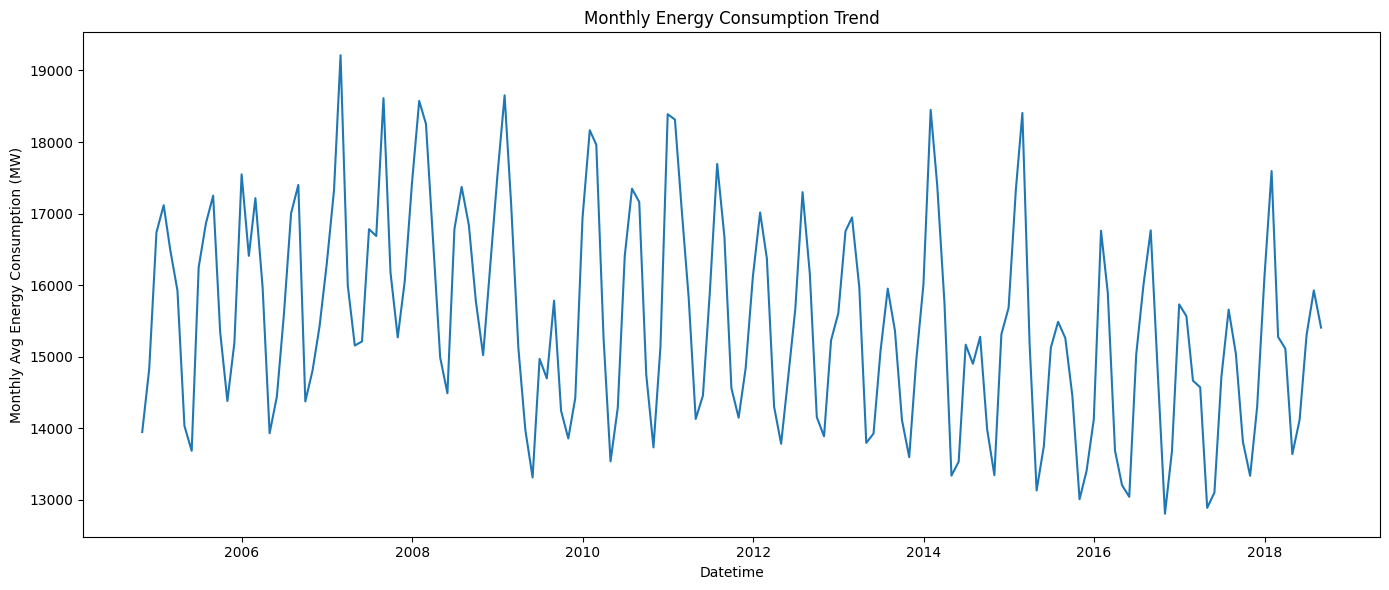

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(df_monthly['Datetime'], df_monthly['AEP_MW'])
plt.xlabel("Datetime")
plt.ylabel("Monthly Avg Energy Consumption (MW)")
plt.title("Monthly Energy Consumption Trend")
plt.tight_layout()
plt.show()

# Feature Engineering
Preprocessing raw data

In [7]:
# converting dates to year, month, day feature
df['year'] = df['Datetime'].dt.year
df['month'] = df['Datetime'].dt.month
df['day'] = df['Datetime'].dt.day
df.head()

,Datetime,AEP_MW,year,month,day
0,2004-12-31 01:00:00,13478.0,2004,12,31
1,2004-12-31 02:00:00,12865.0,2004,12,31
2,2004-12-31 03:00:00,12577.0,2004,12,31
3,2004-12-31 04:00:00,12517.0,2004,12,31
4,2004-12-31 05:00:00,12670.0,2004,12,31


In [8]:
# Converting day of the week {monday = 0 to sunday = 6} and time {hour ; minute ; seconds} to feature
df['day_of_week'] = df['Datetime'].dt.dayofweek
df['hour'] = df['Datetime'].dt.hour
df['minute'] = df['Datetime'].dt.minute
df['second'] = df['Datetime'].dt.second
df.head(100)

,Datetime,AEP_MW,year,month,day,day_of_week,hour,minute,second
0,2004-12-31 01:00:00,13478.0,2004,12,31,4,1,0,0
1,2004-12-31 02:00:00,12865.0,2004,12,31,4,2,0,0
2,2004-12-31 03:00:00,12577.0,2004,12,31,4,3,0,0
3,2004-12-31 04:00:00,12517.0,2004,12,31,4,4,0,0
4,2004-12-31 05:00:00,12670.0,2004,12,31,4,5,0,0
...,...,...,...,...,...,...,...,...,...
95,2004-12-29 00:00:00,16047.0,2004,12,29,2,0,0,0
96,2004-12-27 01:00:00,16718.0,2004,12,27,0,1,0,0
97,2004-12-27 02:00:00,16150.0,2004,12,27,0,2,0,0
98,2004-12-27 03:00:00,16090.0,2004,12,27,0,3,0,0


In [9]:
# Cyclic data encoding
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_day_of_week'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['cos_day_of_week'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df.head(50)

,Datetime,AEP_MW,year,month,day,day_of_week,hour,minute,second,sin_hour,cos_hour,sin_day_of_week,cos_day_of_week
0,2004-12-31 01:00:00,13478.0,2004,12,31,4,1,0,0,2.588190e-01,9.659258e-01,-0.433884,-0.900969
1,2004-12-31 02:00:00,12865.0,2004,12,31,4,2,0,0,5.000000e-01,8.660254e-01,-0.433884,-0.900969
2,2004-12-31 03:00:00,12577.0,2004,12,31,4,3,0,0,7.071068e-01,7.071068e-01,-0.433884,-0.900969
3,2004-12-31 04:00:00,12517.0,2004,12,31,4,4,0,0,8.660254e-01,5.000000e-01,-0.433884,-0.900969
4,2004-12-31 05:00:00,12670.0,2004,12,31,4,5,0,0,9.659258e-01,2.588190e-01,-0.433884,-0.900969
5,2004-12-31 06:00:00,13038.0,2004,12,31,4,6,0,0,1.000000e+00,6.123234e-17,-0.433884,-0.900969
6,2004-12-31 07:00:00,13692.0,2004,12,31,4,7,0,0,9.659258e-01,-2.588190e-01,-0.433884,-0.900969
7,2004-12-31 08:00:00,14297.0,2004,12,31,4,8,0,0,8.660254e-01,-5.000000e-01,-0.433884,-0.900969
8,2004-12-31 09:00:00,14719.0,2004,12,31,4,9,0,0,7.071068e-01,-7.071068e-01,-0.433884,-0.900969
9,2004-12-31 10:00:00,14941.0,2004,12,31,4,10,0,0,5.000000e-01,-8.660254e-01,-0.433884,-0.900969


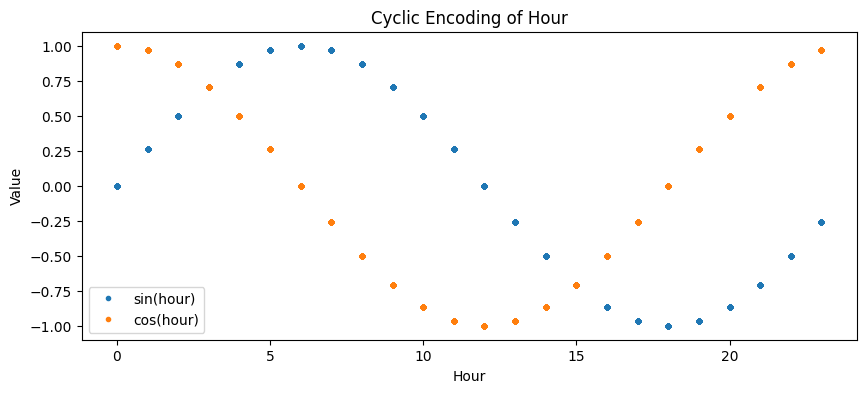

In [10]:
# Graph for Cyclic Hour
plt.figure(figsize=(10, 4))
plt.plot(df['hour'], df['sin_hour'], '.', label='sin(hour)')
plt.plot(df['hour'], df['cos_hour'], '.', label='cos(hour)')
plt.xlabel("Hour")
plt.ylabel("Value")
plt.title("Cyclic Encoding of Hour")
plt.legend()
plt.show()

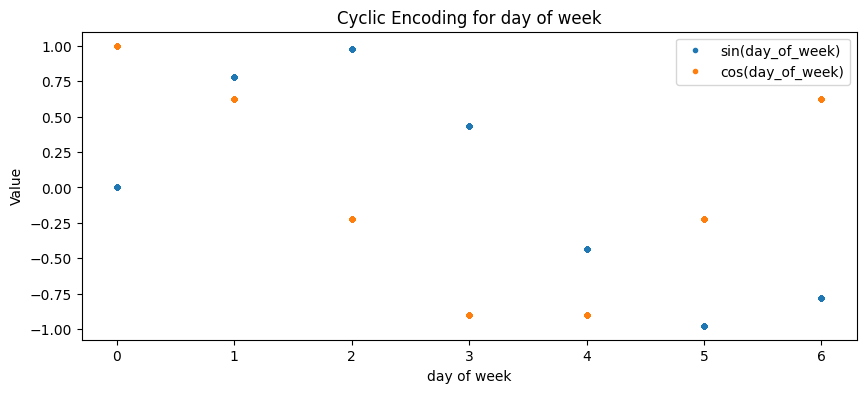

In [11]:
# Graph for cyclic day of week
plt.figure(figsize=(10, 4))
plt.plot(df['day_of_week'], df['sin_day_of_week'], '.', label='sin(day_of_week)')
plt.plot(df['day_of_week'], df['cos_day_of_week'], '.', label='cos(day_of_week)')
plt.xlabel("day of week")
plt.ylabel("Value")
plt.title("Cyclic Encoding for day of week")
plt.legend()
plt.show()

In [12]:
# Dropping datetime, day_of_week, hour, minute and second coloumn
df.drop('Datetime',axis=1,inplace=True)
df.drop('day_of_week',axis=1,inplace=True)
df.drop('hour',axis=1,inplace=True)
df.drop('minute',axis=1,inplace=True)
df.drop('second',axis=1,inplace=True)
df.head()

,AEP_MW,year,month,day,sin_hour,cos_hour,sin_day_of_week,cos_day_of_week
0,13478.0,2004,12,31,0.258819,0.965926,-0.433884,-0.900969
1,12865.0,2004,12,31,0.500000,0.866025,-0.433884,-0.900969
2,12577.0,2004,12,31,0.707107,0.707107,-0.433884,-0.900969
3,12517.0,2004,12,31,0.866025,0.500000,-0.433884,-0.900969
4,12670.0,2004,12,31,0.965926,0.258819,-0.433884,-0.900969


In [13]:
# Moving AEP_MW to last as it is y
df['AEP_MW'] = df.pop('AEP_MW')
df.head()

,year,month,day,sin_hour,cos_hour,sin_day_of_week,cos_day_of_week,AEP_MW
0,2004,12,31,0.258819,0.965926,-0.433884,-0.900969,13478.0
1,2004,12,31,0.500000,0.866025,-0.433884,-0.900969,12865.0
2,2004,12,31,0.707107,0.707107,-0.433884,-0.900969,12577.0
3,2004,12,31,0.866025,0.500000,-0.433884,-0.900969,12517.0
4,2004,12,31,0.965926,0.258819,-0.433884,-0.900969,12670.0


In [14]:
# Saving the new processed dataset
# Reading config.ini
config = configparser.ConfigParser()
config.read('../config.ini')
directory = config['DATASET']['PROCESSED_DATA_DIR'] + "processed_dataset.csv"
df.to_csv("../"+directory)
print("data is cleaned and processed!")

data is cleaned and processed!


# Splitting data for Test, train and valid

In [15]:
Train, Valid, Test = np.split(df, [int(0.6*len(df)), int(0.8*len(df))])

/home/iprabhsidhu/EnergyPrediction/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [16]:
def test_train_split(dataframe):
    X = dataframe.iloc[:,:-1].values
    y = dataframe.iloc[:, -1].values
    return X, y

In [17]:
X_train, y_train = test_train_split(Train)
X_test, y_test = test_train_split(Test)
X_Valid, y_valid = test_train_split(Valid)

# Modelling

In [18]:
import mlflow
from mlflow.models import infer_signature

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression


mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment(config['PROJECT']['PROJECT_NAME'])

with mlflow.start_run():
    LR = LinearRegression()
    LR.fit(X_train, y_train)

    y_pred = LR.predict(X_test)

    logs = {
    'R2 score' : r2_score(y_test, y_pred),
    'MAE' : mean_absolute_error(y_test, y_pred),
    'MSE' : mean_squared_error(y_test, y_pred),
    }

    signature = infer_signature(X_test, y_pred)
    
    mlflow.log_metrics(logs)
    mlflow.sklearn.log_model(
        sk_model = LR,
        name = "Linear regression",
        input_example=X_train,
        registered_model_name = "Sklearn-Linear-Regression-Model",
        signature=signature,
        tags={'problem':'regression','dataset':'kaggle'},
    )
    mlflow.register_model(f'runs:/{mlflow.start_run().info.run_id}/Sklearn-Linear-Regression-Model','Linear Regression')

KeyboardInterrupt: 